In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv')
dataset

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,2
679,841769,2,1,1,1,2,1,1,1,1,2
680,888820,5,10,10,3,7,3,8,10,2,4
681,897471,4,8,6,4,3,4,10,6,1,4


In [5]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv',
                      index_col=0)
dataset
#index_column, dodatna inf, to nam nije bitno za analizu

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
Sample code number,,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1,2
1002945,5,4,4,5,7,10,3,2,1,2
1015425,3,1,1,1,2,2,3,1,1,2
1016277,6,8,8,1,3,4,3,7,1,2
1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2,1,1,1,2
841769,2,1,1,1,2,1,1,1,1,2
888820,5,10,10,3,7,3,8,10,2,4


In [4]:
dataset.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


<Axes: >

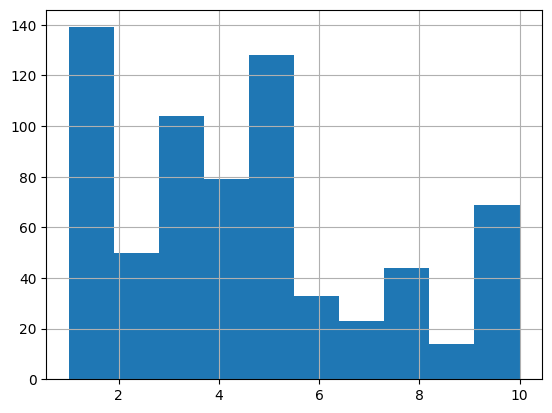

In [6]:
dataset['Clump Thickness'].hist()

In [7]:
dataset.groupby("Class").describe()

Clump Thickness                                                 \
                count      mean       std  min  25%  50%   75%   max   
Class                                                                  
2               444.0  2.963964  1.672661  1.0  1.0  3.0   4.0   8.0   
4               239.0  7.188285  2.437907  1.0  5.0  8.0  10.0  10.0   

      Uniformity of Cell Size            ... Normal Nucleoli       Mitoses  \
                        count      mean  ...             75%   max   count   
Class                                    ...                                 
2                       444.0  1.306306  ...             1.0   8.0   444.0   
4                       239.0  6.577406  ...             9.5  10.0   239.0   

                                                     
           mean       std  min  25%  50%  75%   max  
Class                                                
2      1.065315  0.509738  1.0  1.0  1.0  1.0   8.0  
4      2.602510  2.564495  1.0  1.0  1.0  3.0  10.0  

[2 rows x 72 columns]

In [8]:
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.7 MB/s eta 0:00:00


In [9]:
pg.mwu(dataset[dataset.Class==2]['Mitoses'],
       dataset[dataset.Class==4]['Mitoses'])
#stat značajna razlika u p vrijednosti

,U-val,alternative,p-val,RBC,CLES
MWU,30599.0,two-sided,3.743169e-43,-0.423291,0.288354


In [10]:
dataset['Class'].value_counts()

,count
Class,
2,444
4,239


In [13]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
X.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
Sample code number,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1
1002945,5,4,4,5,7,10,3,2,1
1015425,3,1,1,1,2,2,3,1,1
1016277,6,8,8,1,3,4,3,7,1
1017023,4,1,1,3,2,1,3,1,1


In [14]:
y

,Class
Sample code number,
1000025,2
1002945,2
1015425,2
1016277,2
1017023,2
...,...
776715,2
841769,2
888820,4


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [19]:
X_train.shape

(512, 9)

In [20]:
X_test

array([[-1.22143494, -0.69868992, -0.73961536, ..., -0.98774815,
        -0.62069958, -0.33743902],
       [-0.50794414, -0.69868992, -0.73961536, ..., -0.58605867,
        -0.62069958, -0.33743902],
       [ 0.20554667,  0.61287466,  0.61524355, ...,  0.21732028,
         0.02196611, -0.33743902],
       ...,
       [ 0.20554667, -0.69868992, -0.73961536, ..., -0.18436919,
        -0.62069958,  0.24623928],
       [-0.86468954, -0.37079877, -0.40090064, ...,  1.42238871,
        -0.62069958, -0.33743902],
       [-0.86468954, -0.69868992, -0.73961536, ..., -0.18436919,
        -0.62069958, -0.33743902]])

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, penalty="elasticnet",
                                solver="saga", l1_ratio=0.9)
classifier.fit(X_train, y_train)

LogisticRegression(l1_ratio=0.9, penalty='elasticnet', random_state=0,
                   solver='saga')

In [25]:
pd.DataFrame(X_test, columns=X.columns).describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,0.026131,0.026122,0.042796,0.033094,0.003257,0.092511,-0.022284,-0.079507,0.058506
std,1.024764,1.019792,1.047723,1.035643,0.942086,1.029026,0.934030,0.918488,1.043453
min,-1.221435,-0.698690,-0.739615,-0.636429,-0.990024,-0.680844,-0.987748,-0.620700,-0.337439
25%,-0.864690,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
50%,-0.151199,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.184369,-0.620700,-0.337439
75%,0.562292,0.612875,0.615244,0.244251,0.340402,1.255780,0.619010,0.021966,-0.337439
max,1.989274,2.252330,2.308817,2.534018,3.001253,1.809101,2.627457,2.271296,4.915666


In [22]:
pd.DataFrame(X_train, columns=X.columns)

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
0,0.919037,0.940766,2.308817,0.772659,-0.103073,1.809101,2.225768,2.271296,0.246239
1,1.275783,-0.042908,1.631388,0.068115,0.340402,1.532440,1.824078,1.949963,3.748309
2,1.275783,2.252330,2.308817,2.534018,1.227352,1.809101,2.627457,2.271296,-0.337439
3,-1.221435,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.987748,-0.620700,-0.337439
4,-1.221435,-0.698690,-0.062186,-0.636429,-0.990024,-0.680844,-0.586059,-0.620700,-0.337439
...,...,...,...,...,...,...,...,...,...
507,-0.151199,-0.370799,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
508,0.205547,-0.698690,-0.739615,-0.284157,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439
509,-1.221435,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.987748,-0.620700,-0.337439
510,-0.507944,-0.698690,-0.739615,-0.636429,-0.546549,-0.680844,-0.586059,-0.620700,-0.337439


In [23]:
classifier.coef_

array([[1.08354615, 0.37384472, 0.71652804, 0.51657993, 0.53946807,
        1.5047187 , 0.75418037, 0.68113661, 0.21055724]])

In [30]:
pd.Series(np.squeeze(classifier.coef_), index=X.columns)

,0
Clump Thickness,1.083546
Uniformity of Cell Size,0.373845
Uniformity of Cell Shape,0.716528
Marginal Adhesion,0.516580
Single Epithelial Cell Size,0.539468
Bare Nuclei,1.504719
Bland Chromatin,0.754180
Normal Nucleoli,0.681137
Mitoses,0.210557


<Axes: >

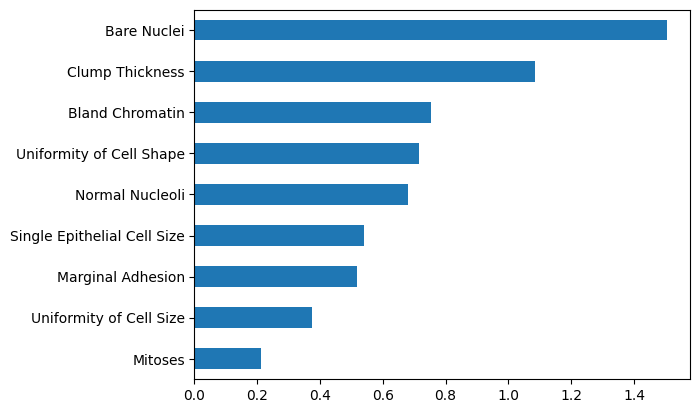

In [24]:
pd.Series(np.squeeze(classifier.coef_), name="coefs", index=X.columns).sort_values().plot.barh()

In [31]:
y_pred = classifier.predict(X_test)
y_pred

array([2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2,
       4, 2, 4, 4, 2, 2, 2, 4, 2, 4, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2,
       2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 4, 2, 4, 2, 2, 4, 2, 4,
       4, 2, 4, 2, 4, 4, 2, 4, 4, 4, 4, 2, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2,
       4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2,
       4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2, 2,
       2, 2, 4, 4, 2, 4, 4, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2])

In [33]:
 from sklearn.metrics import confusion_matrix, accuracy_score

In [34]:
y_pred = pd.Series(y_pred, name='Pred', index=y_test.index)
y_pred

,Pred
Sample code number,
1173347,2
1156017,2
706426,4
1330439,4
693702,2
...,...
1266124,2
1197979,2
764974,2


In [35]:
results = pd.concat([y_test, y_pred], axis=1)
results

,Class,Pred
Sample code number,,
1173347,2,2
1156017,2,2
706426,4,4
1330439,4,4
693702,2,2
...,...,...
1266124,2,2
1197979,2,2
764974,2,2


In [36]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[103   4]
 [  5  59]]


In [37]:
accuracy_score(y_test, y_pred)*100

94.73684210526315